# Lab Assignment 2 - Part A: Linear Regression
Please refer to the `README.pdf` for full laboratory instructions.

## Problem Statement
A dataset is included related to red and white vinho verde wine samples, from the north of Portugal. In this exercise, we look at a subset of the data and try to **predict wine's citric acid level based on other features**.

### Dataset Description
Input variables (based on physicochemical tests):
1. fixed acidity
2. volatile acidity
3. **citric acid** (TARGET - what we want to predict)
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol
12. quality (score between 0 and 10)

### Your Tasks
1. **Implement linear regression** from scratch using least-squares (you may use `np.linalg.lstsq()`)
2. Start with 'alcohol' and 'density' as features. **Find a 3rd feature** that improves prediction the most
3. **Find the 4th feature**. Analyze what happens with all features
4. **Provide plots** comparing predictions vs actual values

## Setup: Load the Dataset
The data is provided through `ucimlrepo`. Install and import required packages below.

In [1]:
!pip install ucimlrepo

12.50s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
# We take 100 samples and predict the citric acid number through various features
X = wine_quality.data.features[:100]
X = X.drop(columns=['citric_acid'])
y = wine_quality.data.features[:100]['citric_acid']
print(X.keys())

Index(['fixed_acidity', 'volatile_acidity', 'residual_sugar', 'chlorides',
       'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH',
       'sulphates', 'alcohol'],
      dtype='object')


### Write and Run Your Own Code

In [3]:
#Library declarations
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Task 1: Implement Linear Regression
# Hint: You can use np.linalg.lstsq() or implement the normal equation: w = (X^T X)^{-1} X^T y

def linear_regression(X, y):
    """
    Implement linear regression using least-squares.
    
    Parameters:
    -----------
    X : numpy array of shape (n_samples, n_features)
    y : numpy array of shape (n_samples,)
    
    Returns:
    --------
    coefficients : numpy array
    """
    X_b = np.hstack([np.ones((X.shape[0], 1)), X])
    coefficients, _, _, _ = np.linalg.lstsq(X_b, y, rcond=None)
    return coefficients
    


def compute_error(X, y, coefficients):
    """
    Compute the prediction error.
    
    Returns:
    --------
    error : float (e.g., RMSE or L2 norm)
    """
    # TODO: Implement this function
    X_b = np.hstack([np.ones((X.shape[0], 1)), X])
    y_pred = X_b @ coefficients
    return np.sqrt(np.mean((y - y_pred) ** 2)) # -RMSE


## Task 2: Start with Two Features
Use 'alcohol' and 'density' as initial features. Train your model and compute the error.

In [5]:
# Create feature matrix with 'alcohol' and 'density'
X_2features = np.vstack((X['alcohol'], X['density'])).T

# TODO: Train model and compute error
model_2 = linear_regression(X_2features, y)
error_2 = compute_error(X_2features, y, model_2)
print(f"Error with 2 features: {error_2:.4f}")


Error with 2 features: 0.1686


## Task 3: Find the 3rd Feature
Try adding each remaining feature one at a time. Which one improves the model the most?

**Hint**: You might want to look at correlations between features.


In [6]:
# TODO: Try each remaining feature and find the best 3rd feature
for key in X.keys():
    if key not in ['alcohol', 'density']:
        X_new = np.vstack((X['alcohol'], X['density'], X[key])).T
        # Train model and compute error
        model = linear_regression(X_new, y)
        error = compute_error(X_new, y, model)
        # Print results
        print(f"{key:30s}  RMSE={error:.4f}")


fixed_acidity                   RMSE=0.1538
volatile_acidity                RMSE=0.1320
residual_sugar                  RMSE=0.1634
chlorides                       RMSE=0.1637
free_sulfur_dioxide             RMSE=0.1675
total_sulfur_dioxide            RMSE=0.1618
pH                              RMSE=0.1605
sulphates                       RMSE=0.1630


## Task 4: Find the 4th Feature and Full Model
Continue the analysis. What is the best 4th feature? What happens when you use all features?


In [7]:
# TODO: Find the best 4th feature
for key in X.keys():
    if key not in ['alcohol', 'density', 'volatile_acidity']:
        X_new = np.vstack((X['alcohol'], X['density'], X['volatile_acidity'], X[key])).T
        model = linear_regression(X_new, y)
        error = compute_error(X_new, y, model)
        print(f"{key:30s}  RMSE={error:.4f}")



# TODO: Train full model with all features
X_all = np.vstack([X[key] for key in X.keys()]).T
model_full = linear_regression(X_all, y)
error_full = compute_error(X_all, y, model_full)
print(f"\nAll features  RMSE={error_full:.4f}")


fixed_acidity                   RMSE=0.1242
residual_sugar                  RMSE=0.1295
chlorides                       RMSE=0.1258
free_sulfur_dioxide             RMSE=0.1307
total_sulfur_dioxide            RMSE=0.1258
pH                              RMSE=0.1283
sulphates                       RMSE=0.1289

All features  RMSE=0.1055


## Task 5: Visualization
Create plots comparing model predictions vs actual values for different feature combinations.


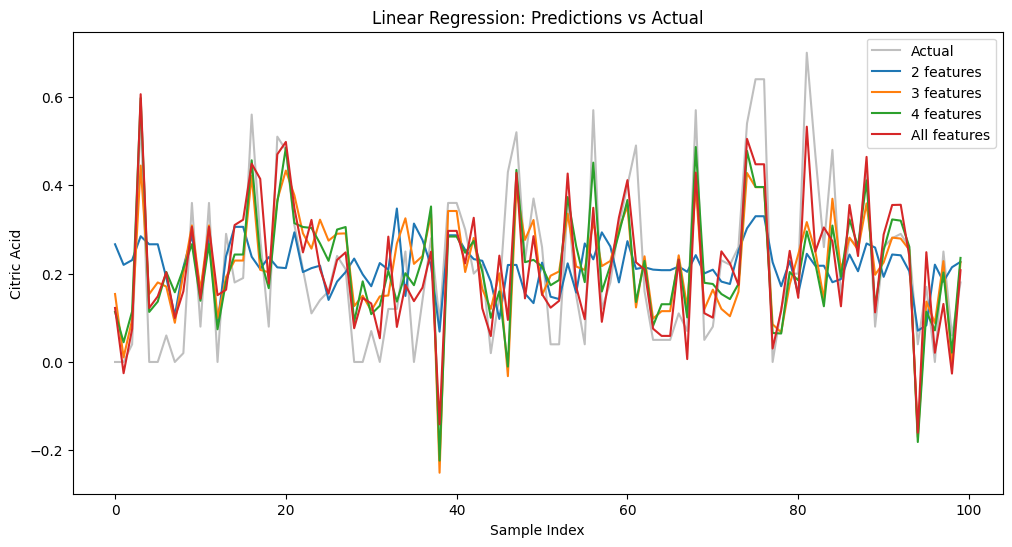

In [10]:
# TODO: Create comparison plots
# Example:
# plt.figure(figsize=(12, 6))
# plt.plot(y, label='Actual', color='gray')
# plt.plot(X_2features @ model_2, label='2 features')
# plt.plot(X_3features @ model_3, label='3 features')
# plt.legend()
# plt.xlabel('Sample Index')
# plt.ylabel('Citric Acid')
# plt.title('Linear Regression: Predictions vs Actual')
# plt.show()
X_3features = np.vstack((X['alcohol'], X['density'], X['volatile_acidity'])).T
X_4features = np.vstack((X['alcohol'], X['density'], X['volatile_acidity'], X['fixed_acidity'])).T

model_3 = linear_regression(X_3features, y)
model_4 = linear_regression(X_4features, y)

def predict(X, w):
    X_b = np.hstack([np.ones((X.shape[0], 1)), X])
    return X_b @ w

configs = [
    ('2 features', X_2features, model_2),
    ('3 features', X_3features, model_3),
    ('4 features', X_4features, model_4),
    ('All features', X_all, model_full),
]

def predict(X, w):
    X_b = np.hstack([np.ones((X.shape[0], 1)), X])
    return X_b @ w


plt.figure(figsize=(12, 6))
plt.plot(y, label='Actual', color='gray', alpha=0.5)
plt.plot(predict(X_2features, model_2), label='2 features')
plt.plot(predict(X_3features, model_3), label='3 features')
plt.plot(predict(X_4features, model_4), label='4 features')
plt.plot(predict(X_all, model_full),    label='All features')
plt.legend()
plt.xlabel('Sample Index')
plt.ylabel('Citric Acid')
plt.title('Linear Regression: Predictions vs Actual')
plt.show()


## Summary and Discussion

### Results Table
| Model | Features | Error |
|-------|----------|-------|
| Model 1 | alcohol, density | 0.168559 |
| Model 2 | alcohol, density,  volatile_acidity  | 0.132040|
| Model 3 | alcohol, density, volatile_acidity , fixed_acidity  | 0.124159 |
| Full Model | all features | 0.105519 |

### Discussion
*Write your analysis here:*
- Which features are most important for predicting citric acid?
volatile_acidity and fixed_acidity gave the biggest RMSE drops after the baseline, likely because citric acid is chemically related to wine acidity
- Does adding more features always improve the model?
Generally yes here, but with decreasing returns, because going from 2 to 3 features cuts RMSE by around 0.03, while going from 4 to all only saved around 0.02 more. More features also creates risk multicollinearity 
- What did you learn from this exercise?
Greedy forward selection is a simple but effective way to identify useful features. The normal equation is fast for small datasets but would be expensive at scale compared to gradient descent